# Análisis exploratorio - Microproyecto - Diabetes Risk

<b> Integrantes: </b>

* Jared Foster Orduz
* Jeferson David Vargas Toca
* Andres Felipe Florez Garces
* Oscar Enrique Morillo

## 0. Imports

A continuación se realizan los imports necesarios para el análisis exploratorio de los datos.  Se debe tener en cuenta que se debe activar el ambiente del proyecto que se llama "venv":

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Lectura de los datos

Se lee el archivo csv que contiene los datos que se van a utilizar en este proyecto y por ende en esta exploración:

In [25]:
ruta_csv = '../data/diabetes_binary_health_indicators_BRFSS2015.csv'

In [26]:
df_datos = pd.read_csv(ruta_csv)
df_datos.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Como no se logra observar bien, se imprimen los nombres de las columnas:

In [27]:
print("Número de columnas:", len(df_datos.columns))
df_datos.columns

Número de columnas: 22


Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Vemos el tipo de dato que es cada una de las variables:

In [28]:
df_datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

Se observa entonces que son 253,680 datos que no son nulos y que todas las variables son de tipo float64, pero quizá hayan variables categóricas escondidas como float64.

A continuación, se muestran las estadísticas de cada una de las variables.

In [30]:
df_datos.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


## 2. Análisis de cada una de las variables

A continuación se va a realizar el análisis de cada una de las variables:

### 2.1. Variable a predecir: Diabetes_binary

Es la variable que se busca predecir, es nuestra "y", si es 0 significa que el paciente no tiene diabetes, si es 1 significa que el paciente tiene prediabetes o diabetes.

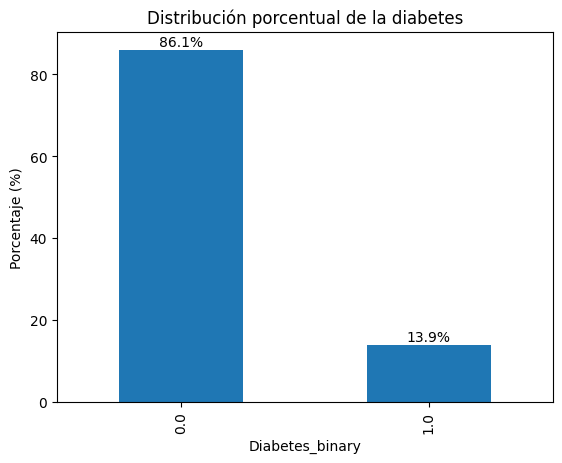

In [44]:
porcentajes = df_datos["Diabetes_binary"].value_counts(normalize=True) * 100
ax = porcentajes.plot(kind="bar")
ax.set_title("Distribución porcentual de la diabetes")
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Diabetes_binary")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Se observa que esta variable está desbalanceada, hay más casos negativos que positivos.

### 2.2. Variables predictoras

Se va a crear una función para mostrar las variables predictores en grupos de 4 variables, esta función va a ser genérica con el fin de poder ser reutilizada y no repetir mucho código:

In [46]:
def graficar_distribuciones(df, variables, titulo):
    
    fig, axes = plt.subplots(1, len(variables), figsize=(5 * len(variables), 5))

    if len(variables) == 1:
        axes = [axes]

    for ax, variable in zip(axes, variables):
        if df[variable].nunique() <= 15:
            porcentajes = (df[variable].value_counts(normalize=True).sort_index() * 100)
            bars = ax.bar(porcentajes.index.astype(str), porcentajes.values)
            ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=11, fontweight="bold")
            ax.set_ylim(0, max(porcentajes.values) * 1.18)
            ax.set_ylabel("Porcentaje (%)")

        else:
            ax.hist(df[variable].dropna(), bins=20)
            ax.set_ylabel("Frecuencia")

        ax.set_title(variable, fontsize=13, fontweight="bold")
        ax.set_xlabel("")

    fig.suptitle(titulo, fontsize=17, fontweight="bold")

    plt.tight_layout()
    plt.show()

Se van a dividir en 6 grupos diferentes de la siguiente manera:

#### 2.2.1. Condiciones cardiovasculares y metabólicas

Este grupo es particularmente importante porque reúne antecedentes y condiciones cardiovasculares que pueden estar asociados con un mayor riesgo metabólico y de diabetes:

* **HighBP:** Presión arterial alta: indica si la persona presenta hipertensión o presión arterial elevada. 0 = No y 1 = Sí.
* **HighChol:** Colesterol alto: indica si la persona presenta niveles elevados de colesterol. 0 = No y 1 = Sí.
* **Stroke:** Accidente cerebrovascular: indica si la persona ha sufrido alguna vez un accidente cerebrovascular. 0 = No y 1 = Sí.
* **HeartDiseaseorAttack:** Enfermedad cardíaca o infarto: indica antecedentes de enfermedad coronaria o infarto de miocardio. 0 = No y 1 = Sí.



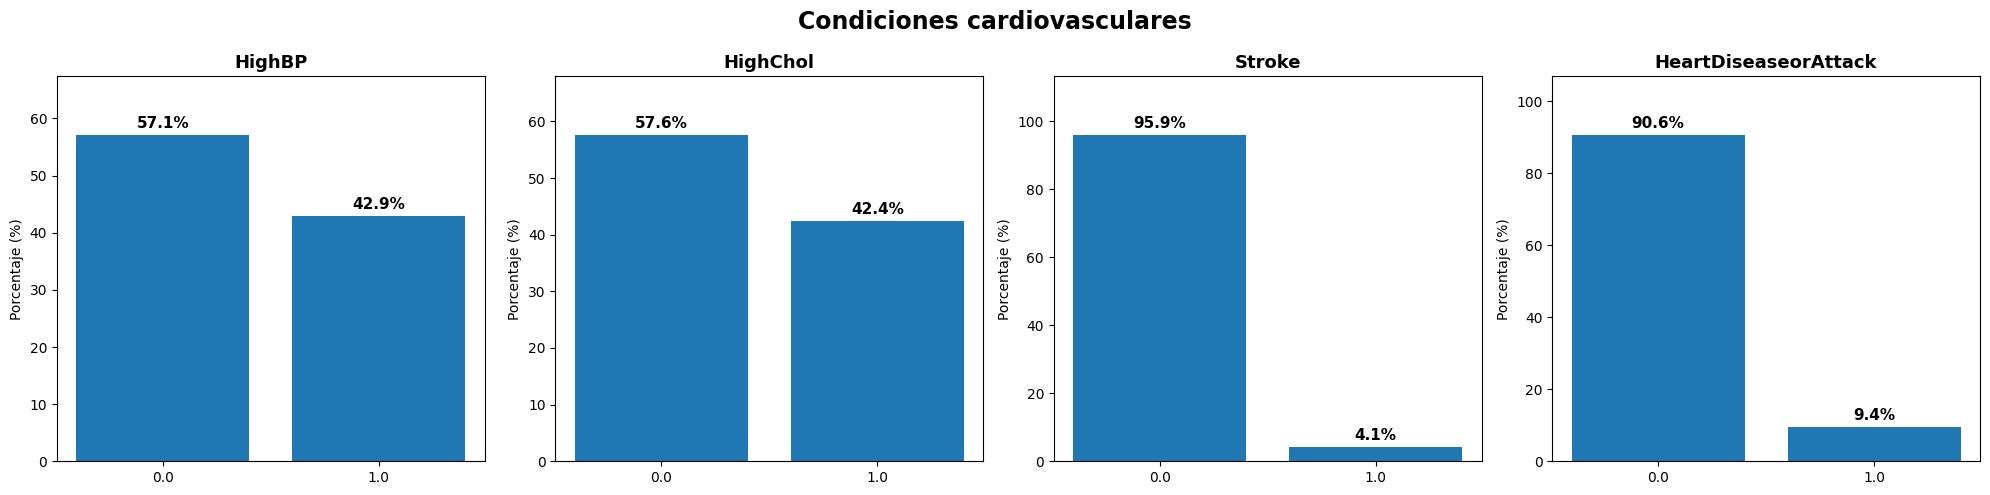

In [49]:
graficar_distribuciones(df_datos, ["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack"], "Condiciones cardiovasculares")

#### 2.2.2. Hábitos y estilos de vida

Estas variables permiten caracterizar algunos de los principales hábitos de vida de la población estudiada:

* **Smoker:** indica si la persona ha fumado al menos 100 cigarrillos durante toda su vida. 0 = No y 1 = Sí.
* **PhysActivity:** actividad física: indica si realizó actividad física o ejercicio durante los últimos 30 días, sin considerar la actividad laboral. 0 = No y 1 = Sí.
* **HvyAlcoholConsump:** identifica personas cuyo consumo de alcohol se clasifica como elevado según los criterios (hombres adultos >= 14 bebidas por semana y mujeres adultas >= 7 bebidas por semana). 0 = No y 1 = Sí.
* **Fruits:** indica si la persona consume frutas una o más veces al día. 0 = No y 1 = Sí.

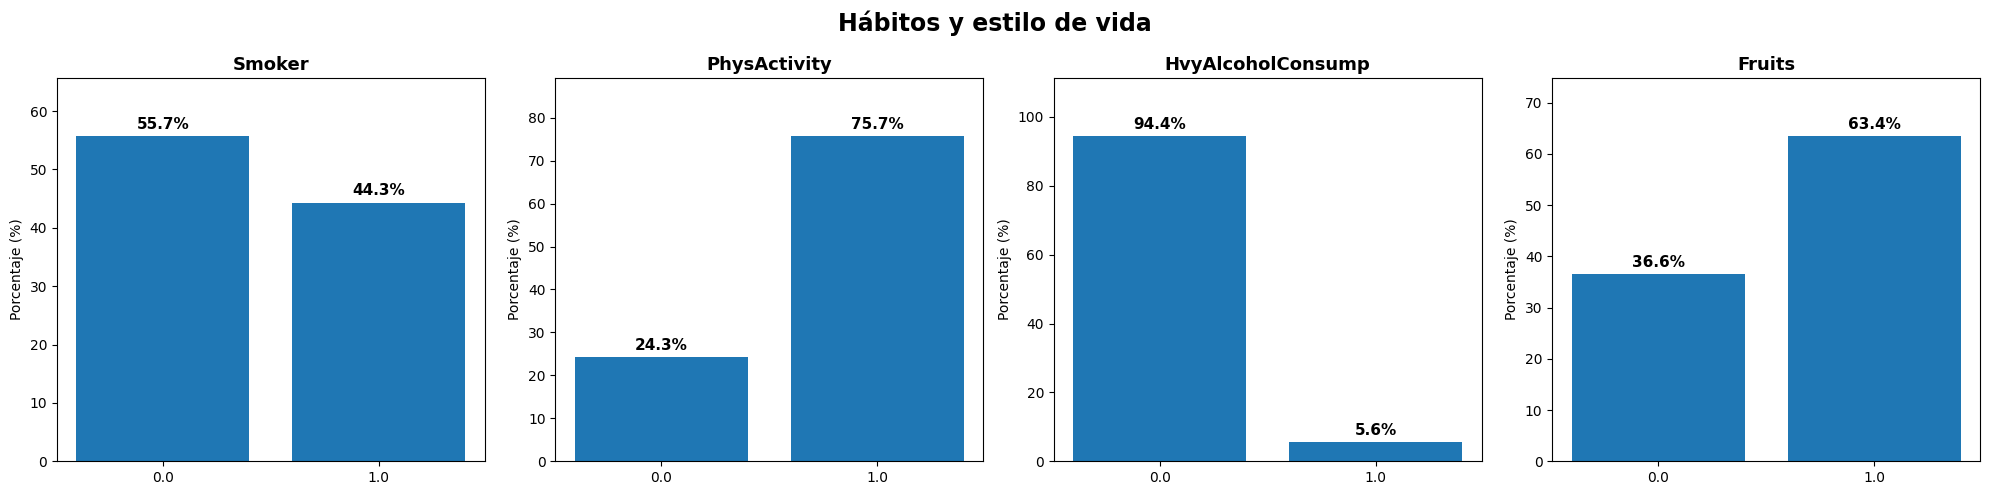

In [51]:
graficar_distribuciones(df_datos, ["Smoker", "PhysActivity", "HvyAlcoholConsump", "Fruits"], "Hábitos y estilo de vida")

#### 2.2.3. Vegetales y acceso a salud

Este bloque ayuda a distinguir factores relacionados con vegetales y acceso al sistema de salud.

* **Veggies:** indica si la persona consume vegetales una o más veces al día. 0 = No y 1 = Sí.
* **CholCheck:** indica si la persona se realizó una medición de colesterol durante los últimos 5 años. 0 = No y 1 = Sí.
* **AnyHealthcare:** indica si la persona cuenta con algún tipo de cobertura o seguro de salud. 0 = No y 1 = Sí.
* **NoDocbcCost:** No acudió al médico por costo: indica si, durante los últimos 12 meses, la persona necesitó consultar a un médico pero no pudo hacerlo debido al costo. 0 = No y 1 = Sí.

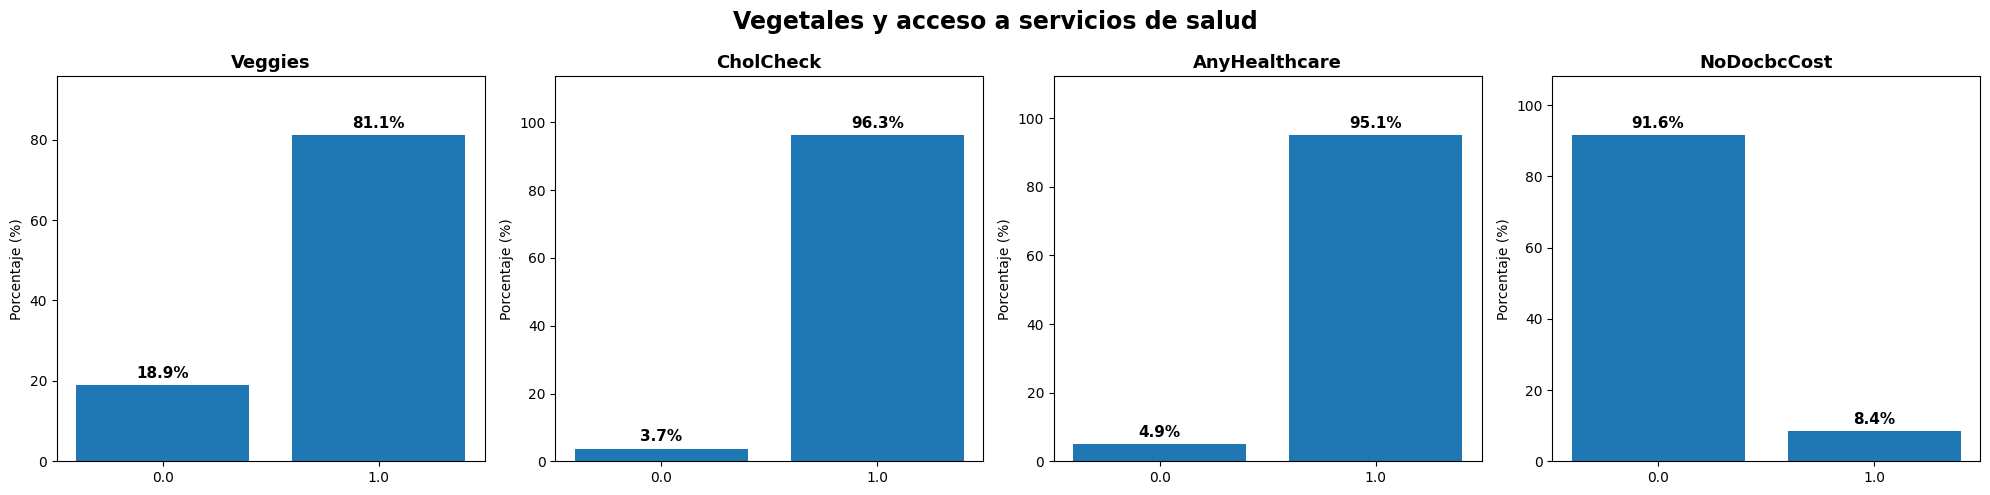

In [56]:
graficar_distribuciones(df_datos, ["Veggies", "CholCheck", "AnyHealthcare", "NoDocbcCost"], "Vegetales y acceso a servicios de salud")

#### 2.2.4. Estado físico del paciente

Este grupo permite analizar tanto medidas físicas y limitaciones físicas.

* **BMI** Mide el índice de Masa Corporal que es una medida que relaciona el peso y la altura de una persona. Es una variable cuantitativa y permite analizar la distribución del peso corporal en la población.
* **GenHlth** El estado general de salud representa la percepción que tiene la persona sobre su estado general de salud. Es una variable ordinal, donde normalmente los valores van desde una percepción excelente (=1) hasta una mala (=5).
* **PhysHlth** representa el número de días durante los últimos 30 días en los que la persona consideró que su salud física no fue buena.
* **DiffWalk** La dificultad para caminar indica si la persona presenta dificultades serias para caminar o subir escaleras. 0 = No y 1 = Sí.

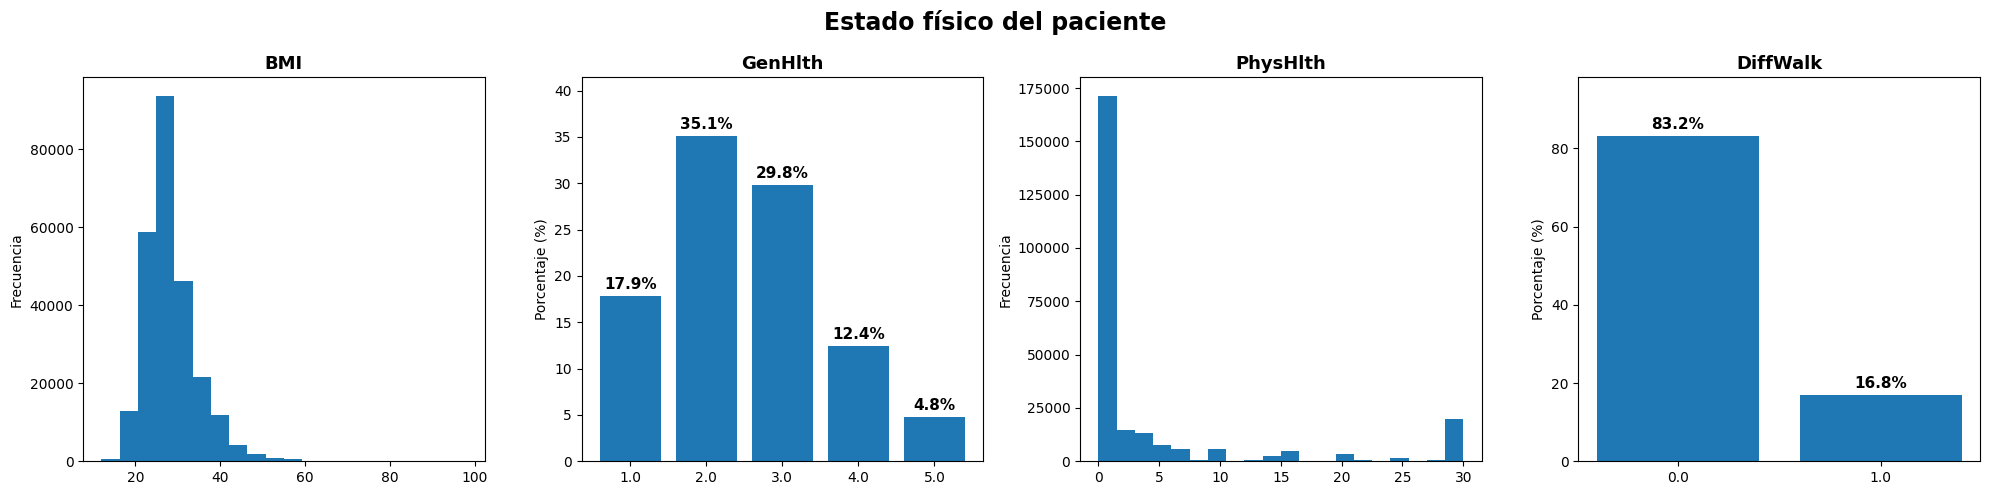

In [54]:
graficar_distribuciones(df_datos, ["BMI", "GenHlth", "PhysHlth", "DiffWalk"], "Estado físico del paciente")

#### 2.2.5. Salud mental y caracteristicas demográficas

Este grupo permite analizar la salud mental y algunas características demográficas de las personas analizadas:

* **MentHlth:** La salud mental corresponde al número de días, durante los últimos 30 días, en los que la persona consideró que su salud mental no fue buena.
* **Sex:** variable binaria utilizada para identificar el sexo reportado por la persona. 0 es mujer y 1 es hombre.
* **Age:** representa la edad mediante categorías o rangos de edad de la forma:<br/>
    - 1=Age 18-24
    - 2=Age 25-29
    - 3=Age 30-34
    - 4=Age 35-39
    - 5=Age 40-44
    - 6=Age 45-49
    - 7=Age 50-54
    - 8=Age 55-59
    - 9=Age 60-64
    - 10=Age 65-69
    - 11=Age 70-74
    - 12=Age 75-79
    - 13=Age 80-older
* **Education:** El nivel educativo es una variable ordinal que representa diferentes niveles de escolaridad alcanzados por la persona, como sigue: <br/>
    - 1: Nunca atendió al colegio o solamente jardín
    - 2: Grados de 1ero a 8vo
    - 3: Grados de 9no a 11
    - 4: Grados de 12 or graduado del colegio
    - 5: Universidad de 1 año a 3 años o una técnica
    - 6: Universidad de 4 años o más

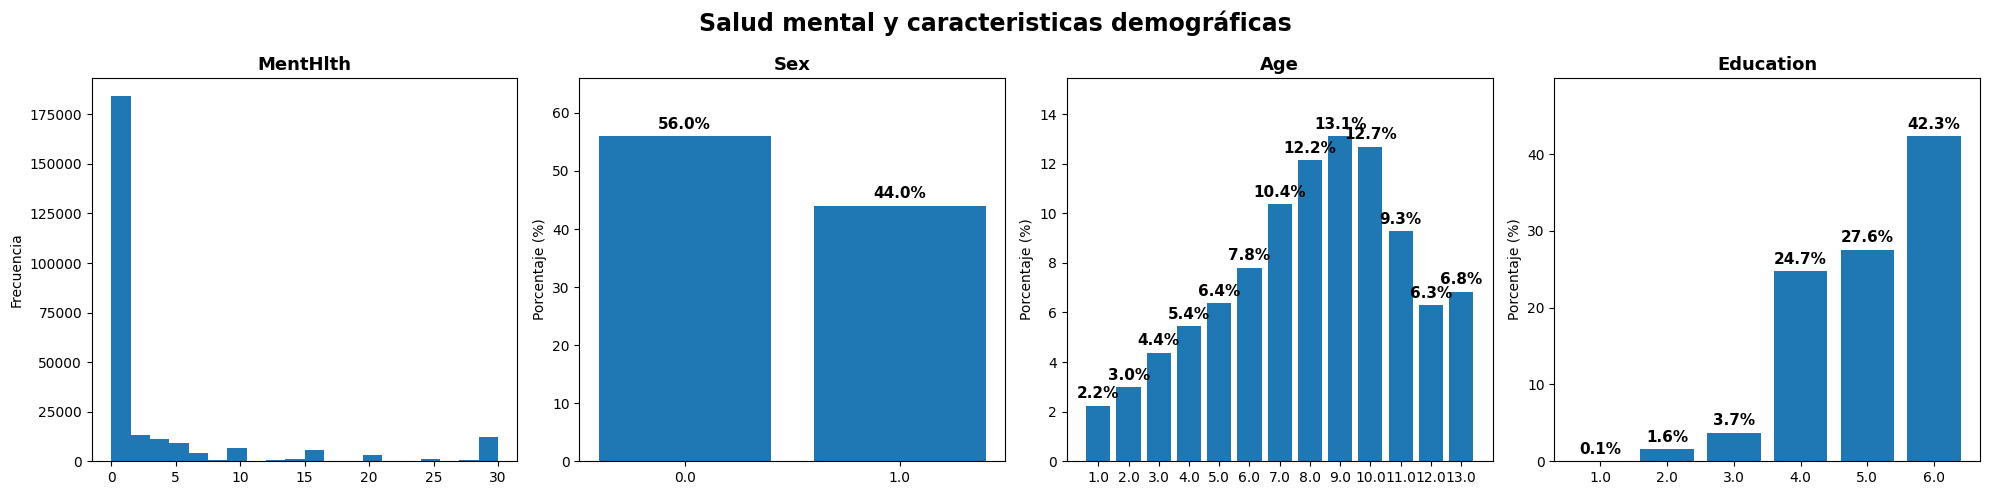

In [55]:
graficar_distribuciones(df_datos, ["MentHlth", "Sex", "Age", "Education"], "Salud mental y caracteristicas demográficas")

#### 2.2.6. Condición socioeconómica

* **Income:** el nivel de ingresos es una variable ordinal que clasifica a las personas según rangos de ingreso. Cada valor corresponde a USD:
  - 1: Menos que $10,000
  - 2: $10,000 a menos que $15,000
  - 3: $15,000 a menos que $20,000
  - 4: $20,000 a menos que $25,000
  - 5: Menos que $35,000 ($25,000 a menos que $35,000)
  - 6: Menos que $50,000 ($35,000 a menos que $50,000)
  - 7: Menos que $75,000 ($50,000 a menos que $75,000)
  - 8: $75,000 o más

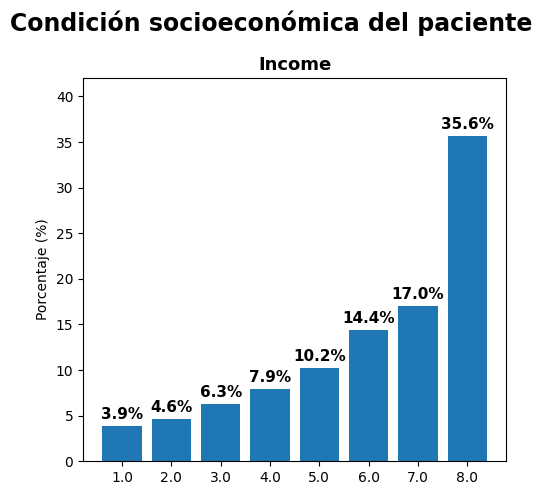

In [57]:
graficar_distribuciones(df_datos, ["Income"], "Condición socioeconómica del paciente")